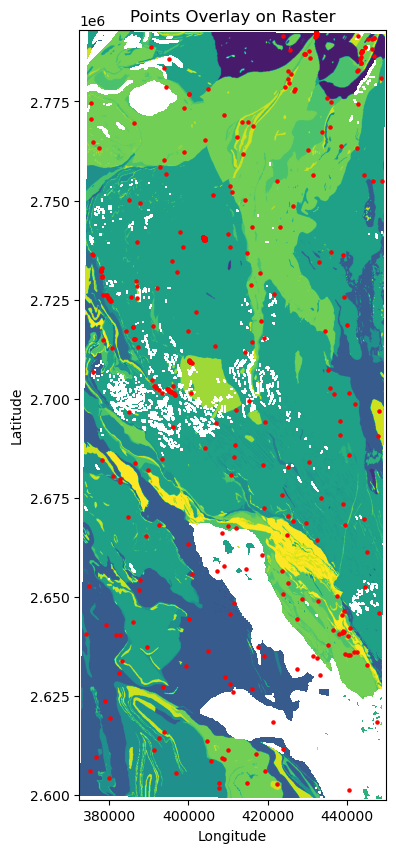

           X           Y  Label  BP1.tif  BP2.tif     BP3.tif     BP4.tif  \
0  440786.81  2642077.56      1    255.0      0.0   18.309561  208.462555   
1  436430.60  2641788.57      1    204.0      0.0   25.893629  196.377960   
2  439430.23  2635532.39      1    204.0      0.0   17.336666  211.162735   
3  441866.23  2636260.49      1    204.0      0.0   90.723312  211.475815   
4  442487.62  2636011.97      1    187.0      0.0  108.053688  208.533401   

      BP5.tif     BP6.tif     BP7.tif     BP8.tif     BP9.tif    BP10.tif  \
0  152.207352  114.003777  234.128418  228.794464  255.000000  189.991425   
1  154.880051   99.249771  234.961914  192.509888  218.571426  189.299408   
2  151.585327  118.567696  229.825272  230.810272  241.339279  161.381027   
3  154.378815   95.339821  230.810394  208.636368  250.446426  172.840439   
4  160.164917  102.080162  230.156189  176.383408  250.446426  167.205093   

     BP11.tif    BP12.tif    BP13.tif   BP14.tif    BP15.tif    BP16.tif  

In [2]:
import pandas as pd
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
from shapely.geometry import Point
import os

# Directory containing raster files

raster_dir = "C:/Users/AMD NR/Untitled Folder/RajML_py/Copper_package"  # Update this path

# List of raster file names
raster_files = [f"BP{i}.tif" for i in range(1, 18)]

# Load the points from the CSV file
points_df = pd.read_csv("CuTS04.csv")

# Create a DataFrame to store results
results_df = points_df.copy()

# Iterate through each raster file
for raster_file in raster_files:
    raster_path = os.path.join(raster_dir, raster_file)
    try:
        with rasterio.open(raster_path) as raster:
            # Extract raster values at the point locations
            coordinates = [(x, y) for x, y in zip(points_df['X'], points_df['Y'])]
            raster_values = [val[0] for val in raster.sample(coordinates)]
            
            # Add raster values to the DataFrame
            results_df[raster_file] = raster_values
    except rasterio.errors.RasterioIOError:
        # Handle the case where the raster file cannot be opened
        results_df[raster_file] = None
# Plotting example: plotting the first raster
fig, ax = plt.subplots(figsize=(10, 10))
if raster_files:
    # Load the first raster to show as an example
    with rasterio.open(os.path.join(raster_dir, raster_files[0])) as raster:
        rasterio.plot.show(raster, ax=ax)
    
    # Overlay the points on the raster plot
    ax.scatter(points_df['X'], points_df['Y'], color='red', s=5)

# Show the plot
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Points Overlay on Raster')
plt.show()

# Display the first few rows with the extracted raster values
print(results_df.head())

# Optionally, save the results to a CSV file
results_df.to_csv("extracted_raster_values.csv", index=False)


In [3]:
#restructuring the results_dataframe for random Forest classifcation
# Drop the first two columns and send label column to the last 
#ML_df is the master dataframe for classification 
ML_df = results_df.drop(columns=['X', 'Y'])
# Extract the third column (Feature3 in this example)
third_column = results_df['Label']

# Drop the third column from the original DataFrame
ML_df = ML_df.drop(columns=['Label'])

# Add the third column to the end of the DataFrame
ML_df['Label'] = third_column 

print(ML_df)
ML_df.to_csv('Cu_ML_base.csv', index=False)

     BP1.tif     BP2.tif     BP3.tif     BP4.tif     BP5.tif     BP6.tif  \
0      255.0    0.000000   18.309561  208.462555  152.207352  114.003777   
1      204.0    0.000000   25.893629  196.377960  154.880051   99.249771   
2      204.0    0.000000   17.336666  211.162735  151.585327  118.567696   
3      204.0    0.000000   90.723312  211.475815  154.378815   95.339821   
4      187.0    0.000000  108.053688  208.533401  160.164917  102.080162   
..       ...         ...         ...         ...         ...         ...   
375     85.0  164.825500   97.361183  213.022705  140.158615  107.765190   
376     85.0   50.487427   34.000000  183.914124   88.356247  100.502457   
377    153.0   73.553246  119.774620  210.870697  160.462372  125.544205   
378    136.0   13.732170   37.400002  208.590103  105.224701  103.957832   
379    204.0    0.000000  118.610794  193.749817  150.994812  109.206306   

        BP7.tif     BP8.tif     BP9.tif    BP10.tif    BP11.tif    BP12.tif  \
0    234

In [4]:
# Example DataFrame loading
# df = pd.read_csv('your_data.csv')

# Assume the last column is the label
X = ML_df.iloc[:, :-1]  # Features
y = ML_df.iloc[:, -1]   # Labels

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


C:\Users\AMD NR\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [10:30:27] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\AMD NR\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [10:30:27] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\AMD NR\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [10:30:27] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\AMD NR\anaconda3\lib\site-packa

C:\Users\AMD NR\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [10:30:28] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\AMD NR\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [10:30:28] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\AMD NR\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [10:30:28] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\AMD NR\anaconda3\lib\site-packa

C:\Users\AMD NR\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [10:30:31] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\AMD NR\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [10:30:31] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\AMD NR\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [10:30:31] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\AMD NR\anaconda3\lib\site-packa

C:\Users\AMD NR\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [10:30:34] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\AMD NR\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [10:30:34] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\AMD NR\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [10:30:34] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\AMD NR\anaconda3\lib\site-packa

...

C:\Users\AMD NR\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [10:32:12] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\AMD NR\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [10:32:13] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\AMD NR\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [10:32:13] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\AMD NR\anaconda3\lib\site-packa

C:\Users\AMD NR\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [10:32:14] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\AMD NR\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [10:32:15] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\AMD NR\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [10:32:15] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\AMD NR\anaconda3\lib\site-packa

C:\Users\AMD NR\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [10:32:16] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\AMD NR\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [10:32:17] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\AMD NR\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [10:32:17] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\AMD NR\anaconda3\lib\site-packa

C:\Users\AMD NR\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [10:32:19] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\AMD NR\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [10:32:19] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Best Parameters from Grid Search:
 {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.7}
Evaluation on Validation Set
Confusion Matrix:
 [[36  2]
 [ 4 34]]
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.95      0.92        38
           1       0.94      0.89      0.92        38

    accuracy                           0.92        76
   macro avg       0.92      0.92      0.92        76
weighted avg       0.92      0.92      0.92        76

Accuracy Score: 0.9210526315789473
ROC AUC Score: 0.9619113573407202


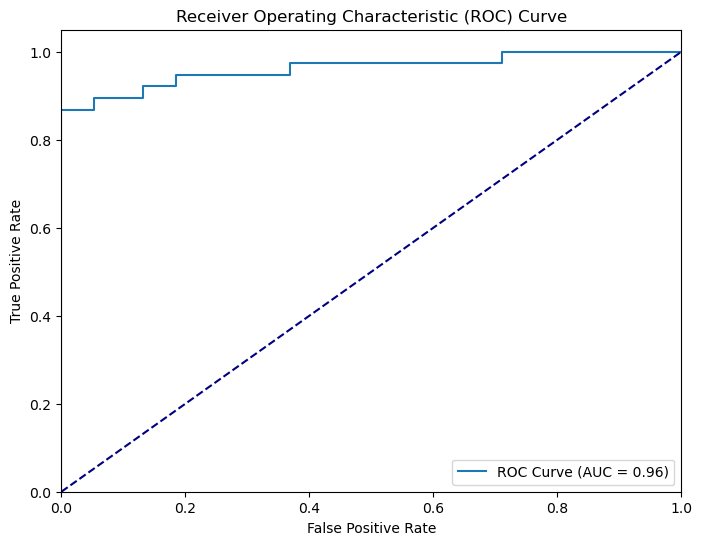

Wall time: 1min 53s


In [5]:
%%time
import xgboost as xgb
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

# Assuming X and y are your features and labels
# Split your data into training and validation sets (80% train, 20% validation)
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Initialize the XGBClassifier
xgb_clf = XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, n_jobs=1)

# Set up the parameter grid for GridSearchCV
param_grid = {
    'learning_rate': [0.01, 0.1, 0.2],  # step size shrinkage
    'max_depth': [3, 5, 6],             # maximum depth of trees
    'n_estimators': [100, 200, 300],     # number of boosting rounds
    'subsample': [0.7, 0.8, 1.0],       # subsample ratio of training instances
    'colsample_bytree': [0.7, 0.8, 1.0] # subsample ratio of columns when constructing trees
}

# Set up GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(estimator=xgb_clf, param_grid=param_grid, cv=5, scoring='accuracy', verbose=1)

# Fit the model using grid search
grid_search.fit(X_train, y_train)

# Get the best hyperparameters and estimator
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

print("Best Parameters from Grid Search:\n", best_params)

# Predictions for Validation Set
y_pred_valid = best_model.predict(X_valid)
y_proba_valid = best_model.predict_proba(X_valid)[:, 1]  # probabilities for ROC AUC

# Evaluation on Validation Set 
print("Evaluation on Validation Set")
print("Confusion Matrix:\n", confusion_matrix(y_valid, y_pred_valid))
print("Classification Report:\n", classification_report(y_valid, y_pred_valid))
print("Accuracy Score:", accuracy_score(y_valid, y_pred_valid))
print("ROC AUC Score:", roc_auc_score(y_valid, y_proba_valid))

# Plotting the ROC curve
fpr, tpr, thresholds = roc_curve(y_valid, y_proba_valid)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc_score(y_valid, y_proba_valid):.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')  # Diagonal line for reference
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


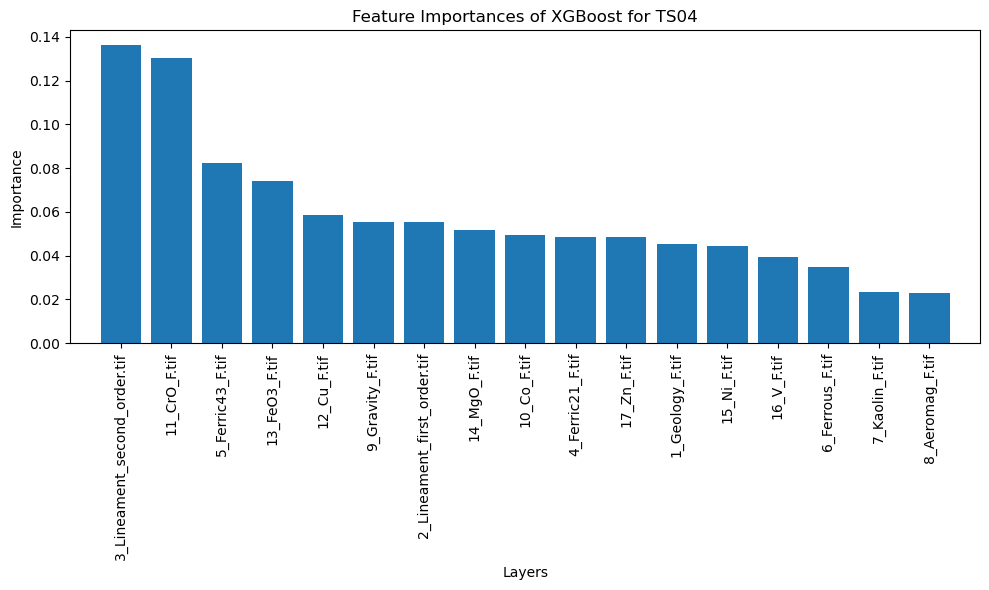

Model saved as 'xgboost_model.joblib'


In [12]:
import matplotlib.pyplot as plt
import joblib
import xgboost as xgb

# Define layer names and their corresponding file names
layer_names = {
    '1_Geology_F.tif': 'BP1.tif',
    '2_Lineament_first_order.tif': 'BP2.tif',
    '3_Lineament_second_order.tif': 'BP3.tif',
    '4_Ferric21_F.tif': 'BP4.tif',
    '5_Ferric43_F.tif': 'BP5.tif',
    '6_Ferrous_F.tif': 'BP6.tif',
    '7_Kaolin_F.tif': 'BP7.tif',
    '8_Aeromag_F.tif': 'BP8.tif',
    '9_Gravity_F.tif': 'BP9.tif',
    '10_Co_F.tif': 'BP10.tif',
    '11_CrO_F.tif': 'BP11.tif',
    '12_Cu_F.tif': 'BP12.tif',
    '13_FeO3_F.tif': 'BP13.tif',
    '14_MgO_F.tif': 'BP14.tif',
    '15_Ni_F.tif': 'BP15.tif',
    '16_V_F.tif': 'BP16.tif',
    '17_Zn_F.tif': 'BP17.tif'
}

# Get feature importances from the trained XGBoost model
importances = best_model.feature_importances_

# Sort the feature importances in descending order
indices = np.argsort(importances)[::-1]

# Create a bar plot
plt.figure(figsize=(10, 6))
plt.title("Feature Importances of XGBoost for TS04")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), np.array(list(layer_names.keys()))[indices], rotation=90)  # Use BP keys as x-tick labels
plt.xlim([-1, len(importances)])
plt.ylabel("Importance")
plt.xlabel("Layers")
plt.tight_layout()
plt.show()

# Save the trained model as a .joblib file
joblib.dump(best_model, 'xgboost_model.joblib')
print("Model saved as 'xgboost_model.joblib'")

In [7]:
import rasterio
import numpy as np
import os
from sklearn.ensemble import RandomForestClassifier
from joblib import load

# Load the trained model
rf_model = load('xgboost_model.joblib')  # Replace with your model file

# Define a function to read rasters and stack them
def stack_rasters(raster_paths):
    """Stack multiple raster files (features) into a single 3D array."""
    raster_stack = []
    min_height = float('inf')
    min_width = float('inf')

    # First, determine the minimum dimensions
    for raster_path in raster_paths:
        with rasterio.open(raster_path) as src:
            height, width = src.shape
            min_height = min(min_height, height)
            min_width = min(min_width, width)

    # Now read and trim each raster
    for raster_path in raster_paths:
        with rasterio.open(raster_path) as src:
            data = src.read(1)  # Read the first band of each raster
            trimmed_data = data[:min_height, :min_width]  # Trim to the minimum size
            raster_stack.append(trimmed_data)

    # Convert list of 2D arrays to a 3D numpy array
    return np.stack(raster_stack, axis=-1)

# Directory containing raster files
raster_dir = "C:/Users/AMD NR/Untitled Folder/RajML_py/Copper_package"

# Paths to the 17 raster files (assumed to be named BP1.tif, BP2.tif, ..., BP17.tif)
raster_paths = [os.path.join(raster_dir, f'BP{i}.tif') for i in range(1, 18)]

# Load and stack rasters
try:
    stacked_rasters = stack_rasters(raster_paths)  # Shape: (min_height, min_width, num_features)
except ValueError as e:
    print(e)
    exit()

# Reshape data to match the model's input
height, width, num_features = stacked_rasters.shape
reshaped_data = stacked_rasters.reshape(-1, num_features)  # Shape: (num_pixels, num_features)

# Handle NaN values
reshaped_data = reshaped_data[~np.isnan(reshaped_data).any(axis=1)]

# Apply the Random Forest model to predict for each pixel
predictions = rf_model.predict(reshaped_data)

# Reshape predictions back to the original image shape
predictions_reshaped = predictions.reshape(height, width)

# Save the prediction as a new raster
output_raster_path = os.path.join(raster_dir, "XGBTS04_cu.tif")

with rasterio.open(raster_paths[0]) as src:
    meta = src.meta  # Get the metadata of the original raster
    meta.update(count=1, dtype='int16', nodata=-9999)  # Update metadata for the prediction raster

    # Write the prediction raster
    with rasterio.open(output_raster_path, 'w', **meta) as dst:
        dst.write(predictions_reshaped.astype('int16'), 1)  # Save as int16

print("Prediction raster saved at:", output_raster_path)


Prediction raster saved at: C:/Users/AMD NR/Untitled Folder/RajML_py/Copper_package\XGBTS04_cu.tif
